In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [8]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.4458
Epoca [10/100] | Loss: 0.1883
Epoca [20/100] | Loss: 0.0592
Epoca [30/100] | Loss: 0.0223
Epoca [40/100] | Loss: 0.0113
Epoca [50/100] | Loss: 0.0068
Epoca [60/100] | Loss: 0.0049
Epoca [70/100] | Loss: 0.0038
Epoca [80/100] | Loss: 0.0034
Epoca [90/100] | Loss: 0.0032
Epoca [100/100] | Loss: 0.0028

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0123
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0001


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

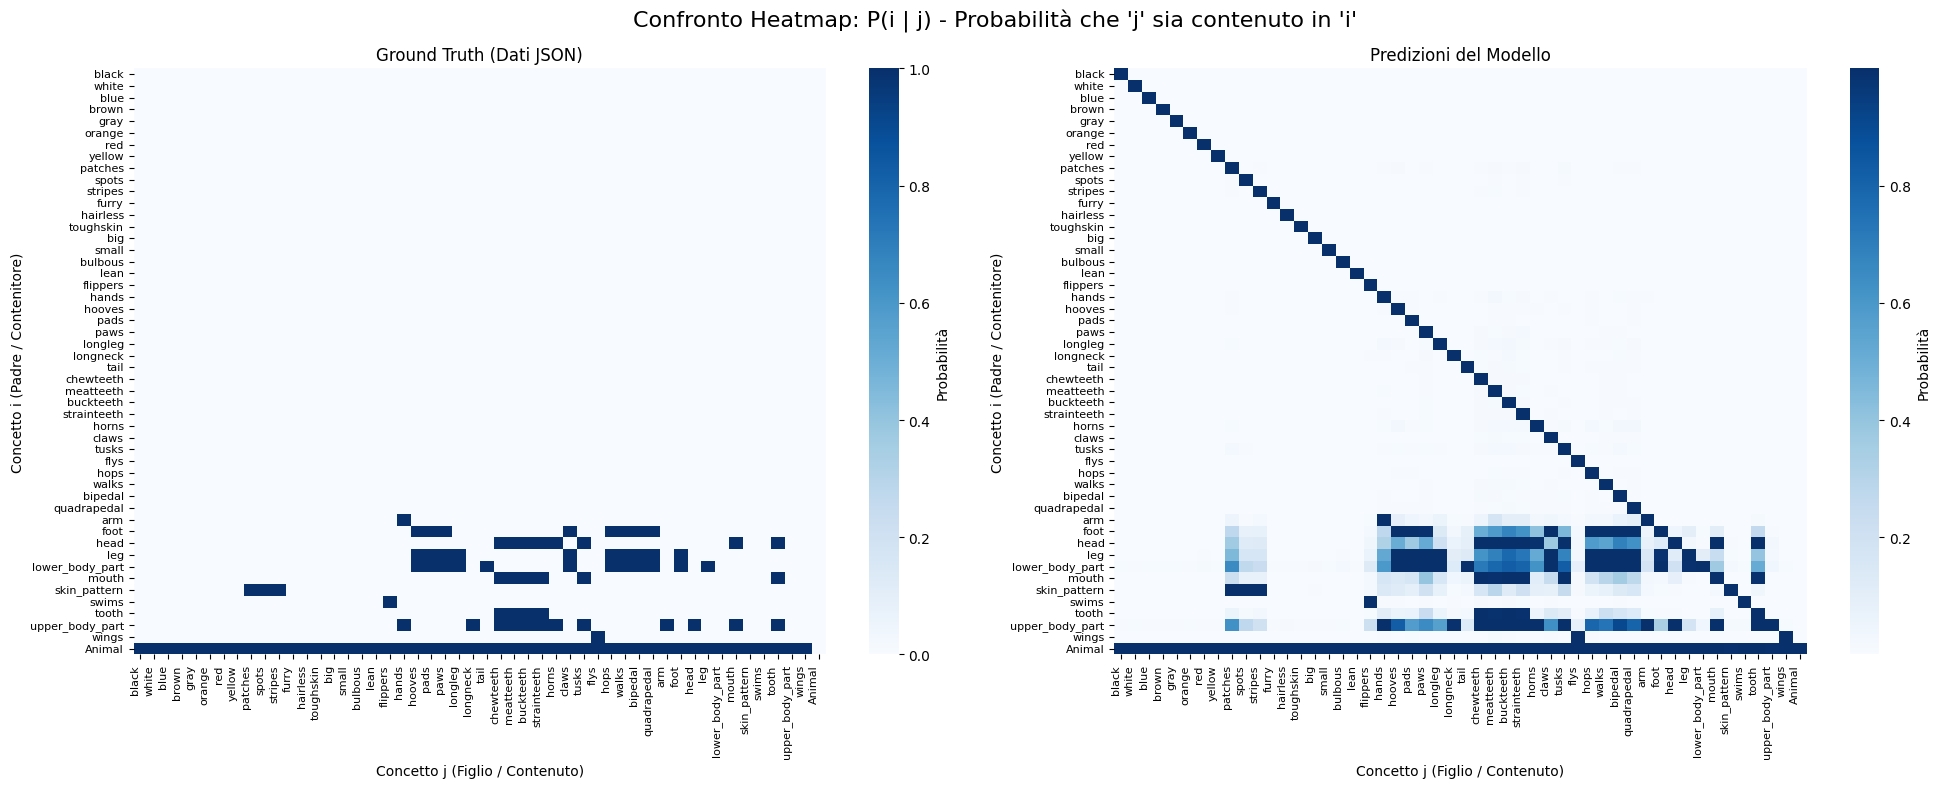

In [10]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

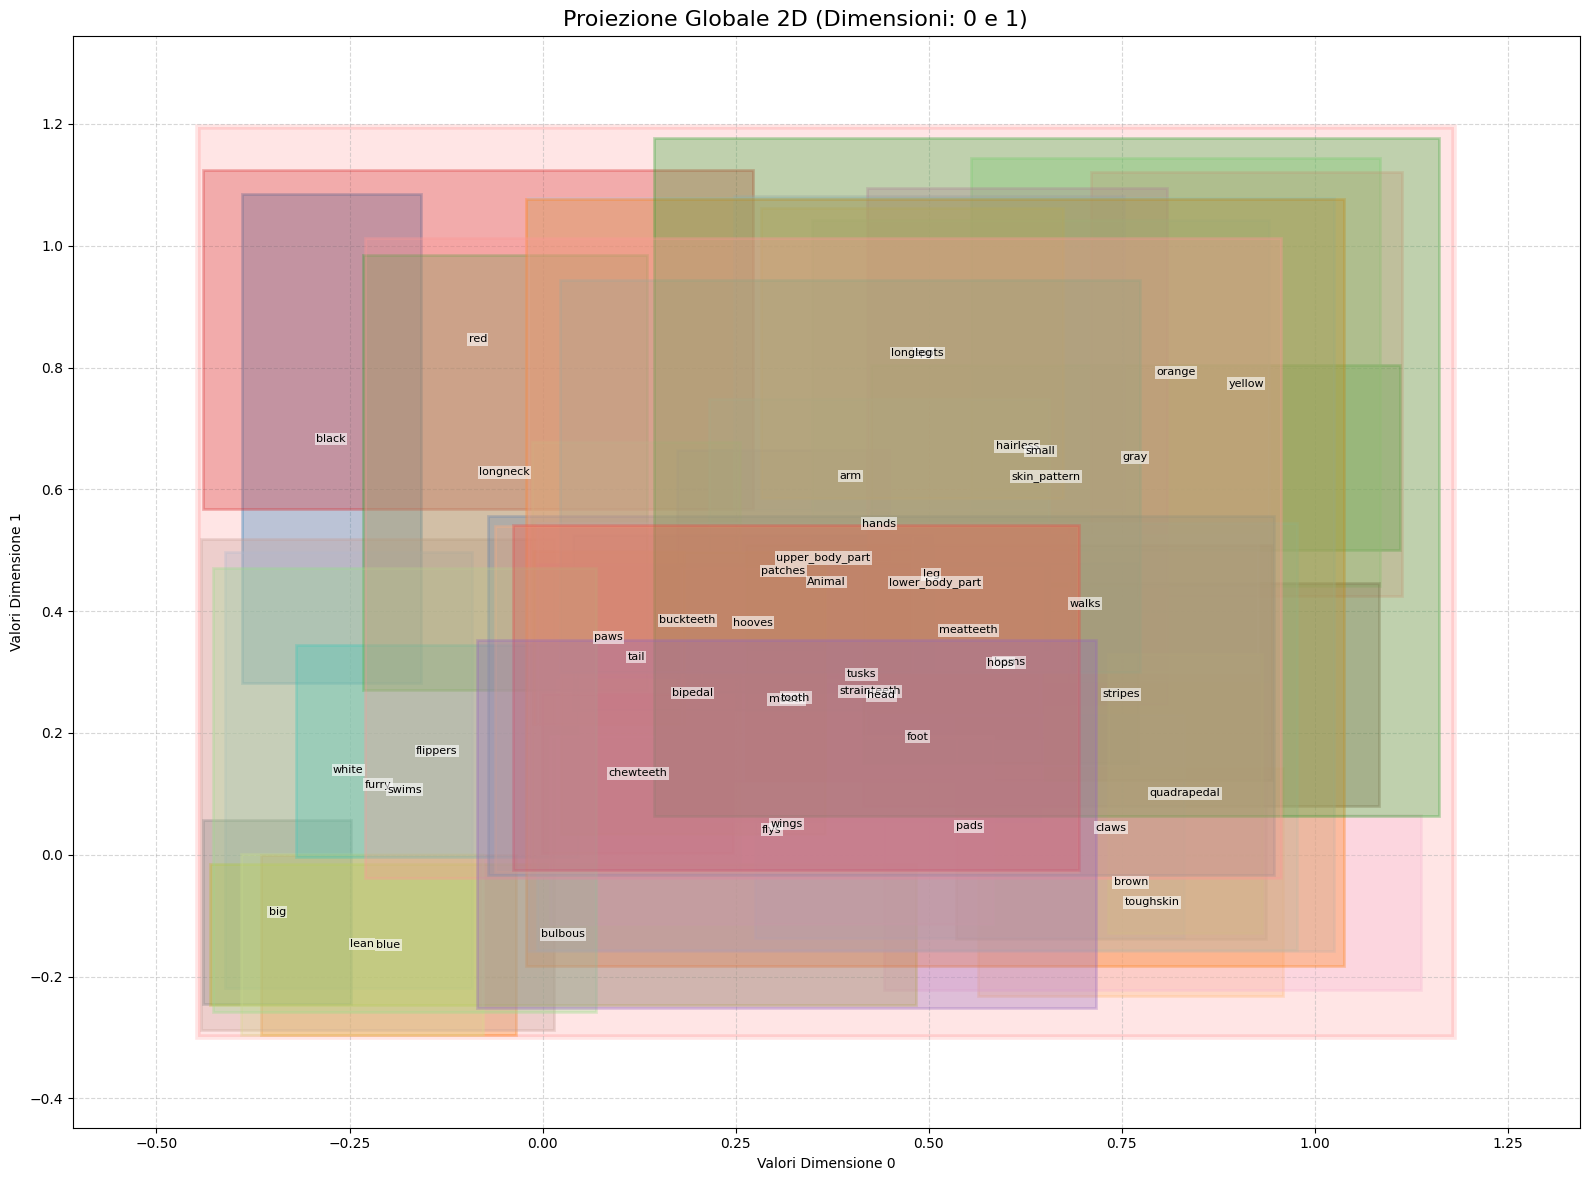

In [11]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

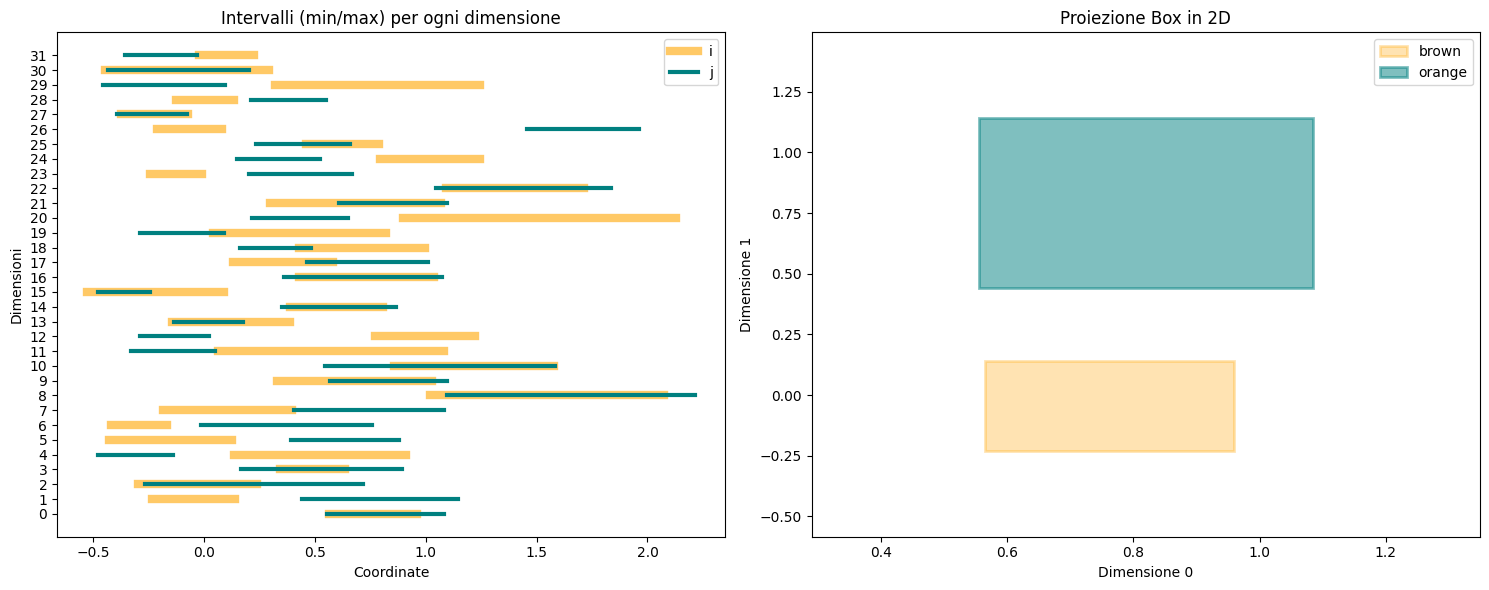

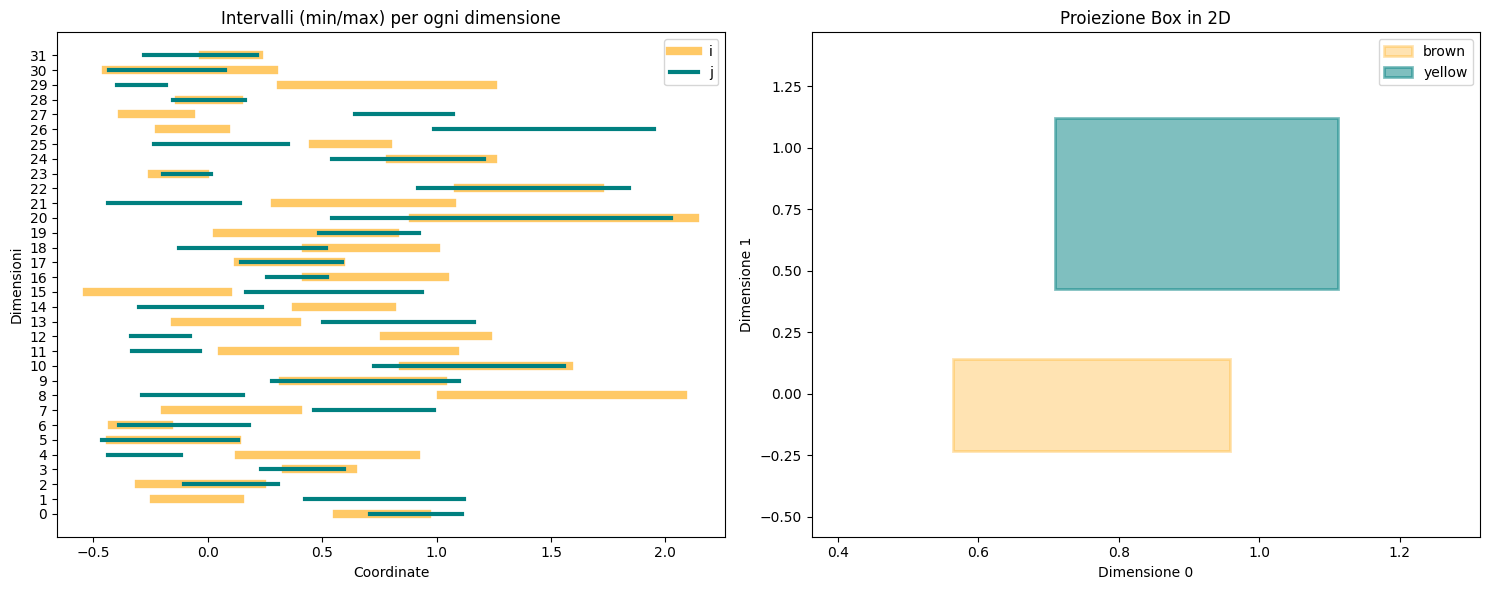

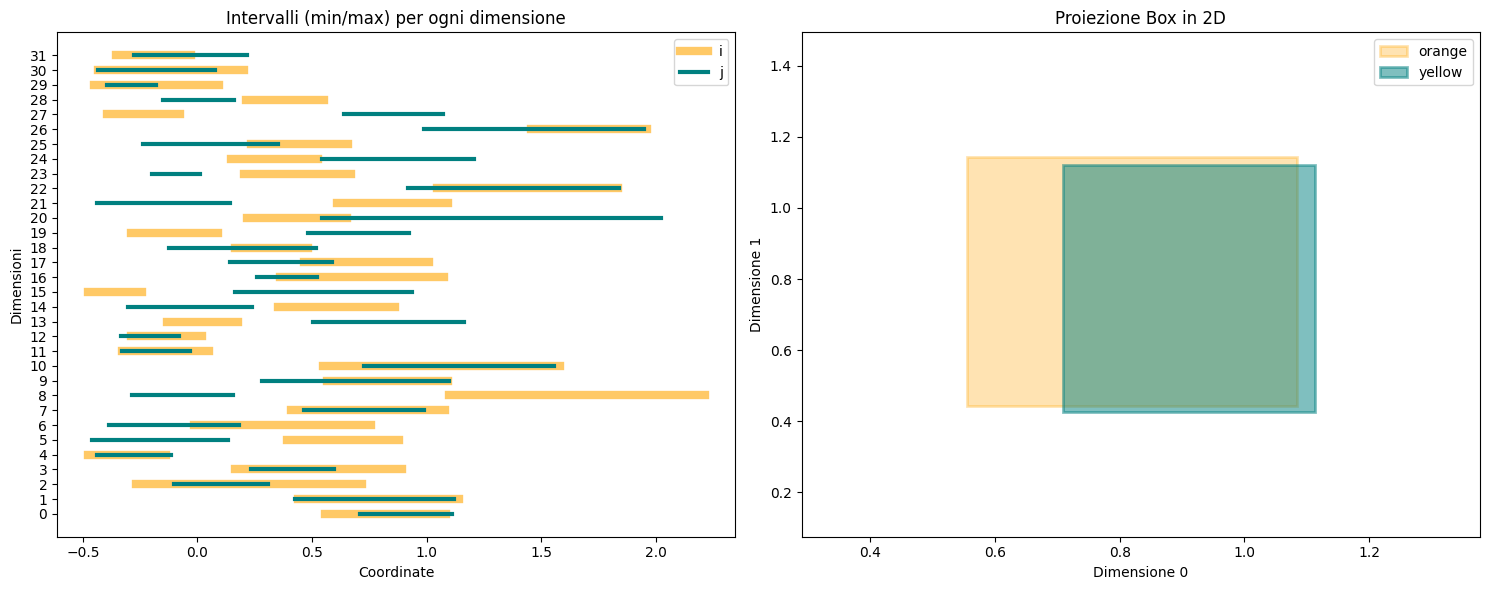

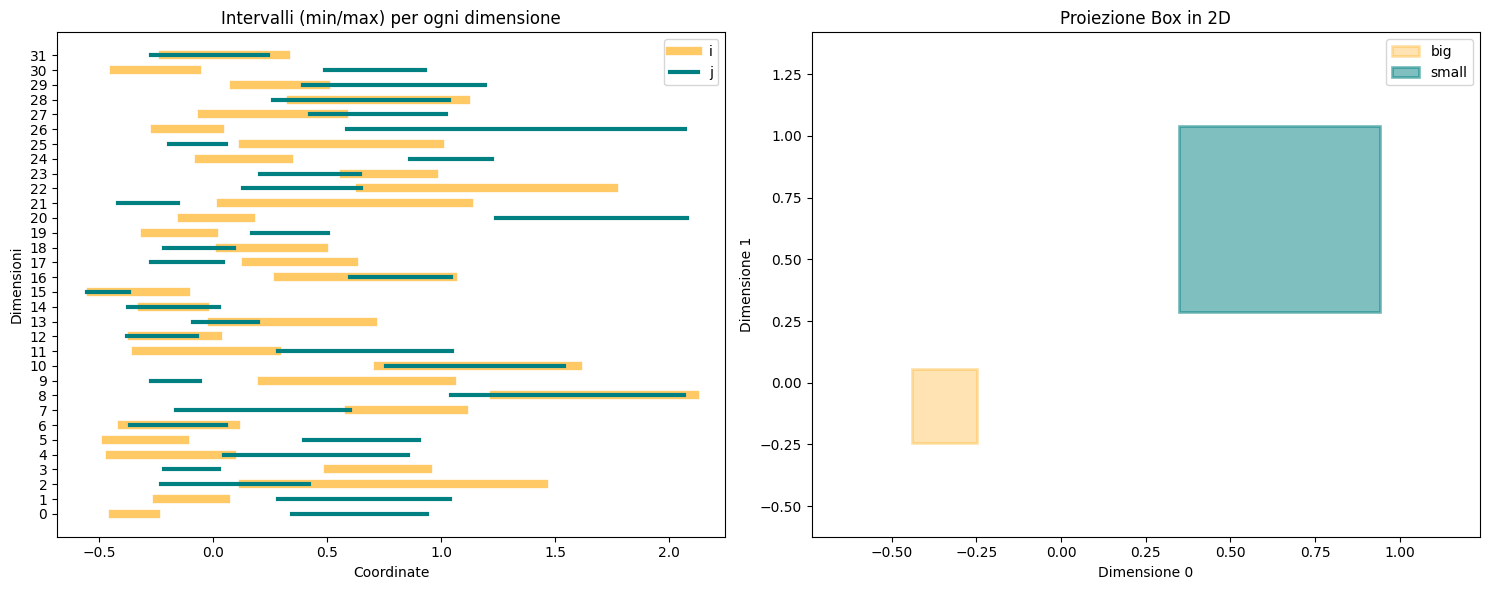

In [12]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [13]:
from src.CHM.model import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

In [14]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.1808, 1.1950, 1.5765, 0.9397, 1.0517, 1.0181, 0.9025, 1.1090, 2.2378,
         1.1128, 1.6685, 1.2308, 1.3546, 1.2956, 0.9996, 1.0028, 1.2244, 1.0856,
         1.1262, 0.9879, 2.1615, 1.1461, 1.8547, 0.9831, 1.3436, 0.9916, 2.0875,
         1.1963, 1.1905, 1.3542, 1.0419, 1.1471]])
Coordinate z (min) per 'wings': tensor([[-0.0845, -0.2515, -0.3120,  0.0437, -0.4487,  0.5244, -0.3587,  0.3921,
          0.7550,  0.2538,  1.0739, -0.2398, -0.1024,  0.5957,  0.0291, -0.4607,
          0.1471, -0.0058,  0.2230, -0.2147,  0.5951, -0.2596,  0.6387, -0.1578,
          0.4860,  0.0624,  0.5271, -0.2232,  0.2659,  0.2810, -0.3688,  0.4279]])


## CBM

### Load dataset

In [15]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [16]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [17]:
box_dict = get_box_dict(box_model, id2concept)

In [18]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.1808, 1.1950, 1.5765, 0.9397, 1.0517, 1.0181, 0.9025, 1.1090, 2.2378,
         1.1128, 1.6685, 1.2308, 1.3546, 1.2956, 0.9996, 1.0028, 1.2244, 1.0856,
         1.1262, 0.9879, 2.1615, 1.1461, 1.8547, 0.9831, 1.3436, 0.9916, 2.0875,
         1.1963, 1.1905, 1.3542, 1.0419, 1.1471]])
Coordinate z (min) per 'wings': tensor([[-0.0845, -0.2515, -0.3120,  0.0437, -0.4487,  0.5244, -0.3587,  0.3921,
          0.7550,  0.2538,  1.0739, -0.2398, -0.1024,  0.5957,  0.0291, -0.4607,
          0.1471, -0.0058,  0.2230, -0.2147,  0.5951, -0.2596,  0.6387, -0.1578,
          0.4860,  0.0624,  0.5271, -0.2232,  0.2659,  0.2810, -0.3688,  0.4279]])


In [19]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.CHM.model import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [20]:
from src.CHM.model import ConceptBottleneckClassifier, ConceptPredictor
from src.CHM.train import train_cbm_classifier, sequential_training, train_concept_predictor
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier, plot_test_results, test_sequential_cbm

### CBM with boxes

#### Train

In [ ]:
b_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
b_cls_optimizer = torch.optim.Adam(b_cls.parameters(), lr=0.001)
b_cls_criterion = nn.CrossEntropyLoss()

b_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
b_concept_optimizer = torch.optim.Adam(b_concept_predictor.parameters(), lr=0.001)
b_concept_criterion = nn.BCEWithLogitsLoss()

info = "boxes"

b_conc_history, b_cls_history = sequential_training(
    b_cls,
    b_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    b_cls_optimizer,  
    b_concept_optimizer,
    b_cls_criterion,
    b_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

In [ ]:
from src.CHM.train import plot_history
plot_history(b_conc_history)

In [ ]:
plot_history(b_cls_history)

#### Test

In [ ]:
accuracy, preds, labels = test_sequential_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    b_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=b_concept_predictor,
    target_class="ox"
)

### CBM with cond prob distrib

#### Train

In [21]:
info = "rel_matrix"
bipolar = True
cp_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
cp_optimizer = torch.optim.Adam(cp_cls.parameters(), lr=0.001)
cp_criterion = nn.CrossEntropyLoss()

cp_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
cp_concept_optimizer = torch.optim.Adam(cp_concept_predictor.parameters(), lr=0.001)
cp_concept_criterion = nn.BCEWithLogitsLoss()

cp_conc_history, cp_cls_history = sequential_training(
    cp_cls,
    cp_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    cp_optimizer,  
    cp_concept_optimizer,
    cp_criterion,
    cp_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5473 | Acc: 95.9431 || Val Loss: 2.6065 | Val Acc: 96.9429
Loss: 2.2495 | Acc: 97.4418 || Val Loss: 2.3651 | Val Acc: 97.2371
Loss: 1.9516 | Acc: 97.7575 || Val Loss: 2.2042 | Val Acc: 97.4091
Loss: 1.7754 | Acc: 97.9529 || Val Loss: 2.1490 | Val Acc: 97.4766
Loss: 1.6628 | Acc: 98.0794 || Val Loss: 2.2378 | Val Acc: 97.4139
Loss: 1.5674 | Acc: 98.1911 || Val Loss: 2.1592 | Val Acc: 97.4867
Loss: 1.4935 | Acc: 98.2827 || Val Loss: 2.2049 | Val Acc: 97.4503
Loss: 1.4331 | Acc: 98.3433 || Val Loss: 2.1388 | Val Acc: 97.5167
Loss: 1.3788 | Acc: 98.4110 || Val Loss: 2.2122 | Val Acc: 97.4846
Loss: 1.3402 | Acc: 98.4564 || Val Loss: 2.2445 | Val Acc: 97.4514
Loss: 1.2979 | Acc: 98.4988 || Val Loss: 2.2072 | Val Acc: 97.5135
Loss: 1.2620 | Acc: 98.5454 || Val Loss: 2.2389 | Val Acc: 97.4916
Loss: 1.2344 | Acc: 98.5691 || Val Loss: 2.2604 | Val Acc: 97.4819
Loss: 1.2049 | Acc: 98.6174 || Val Loss: 2.2428 | Val Ac

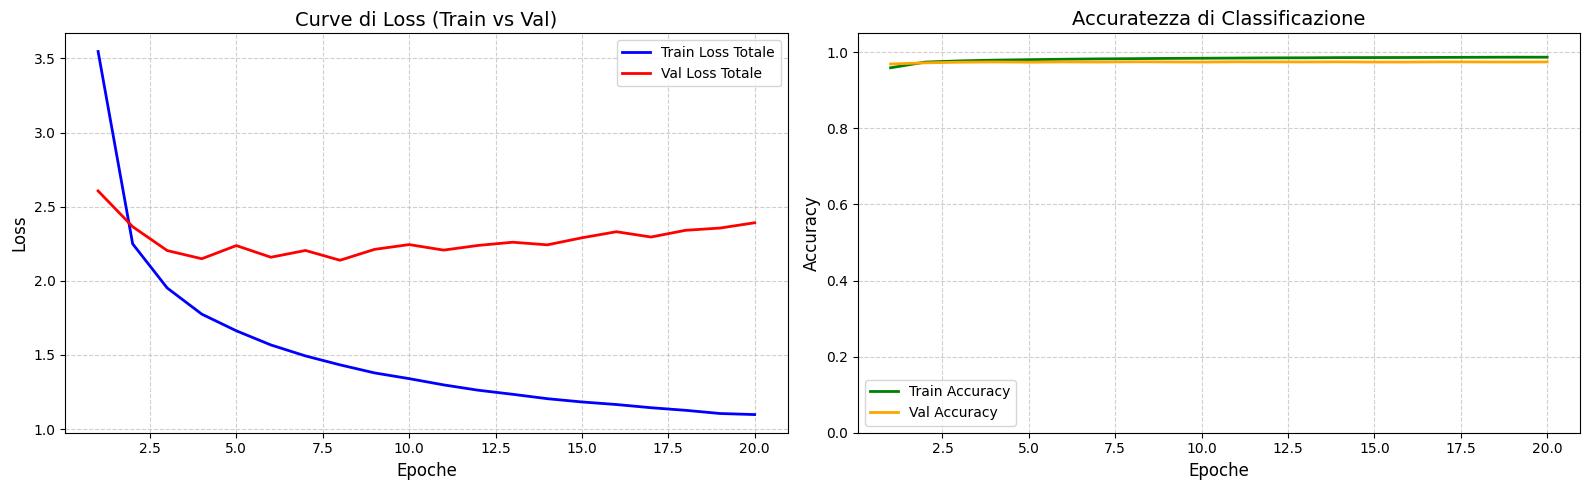

In [22]:
from src.CHM.train import plot_history
plot_history(cp_conc_history)

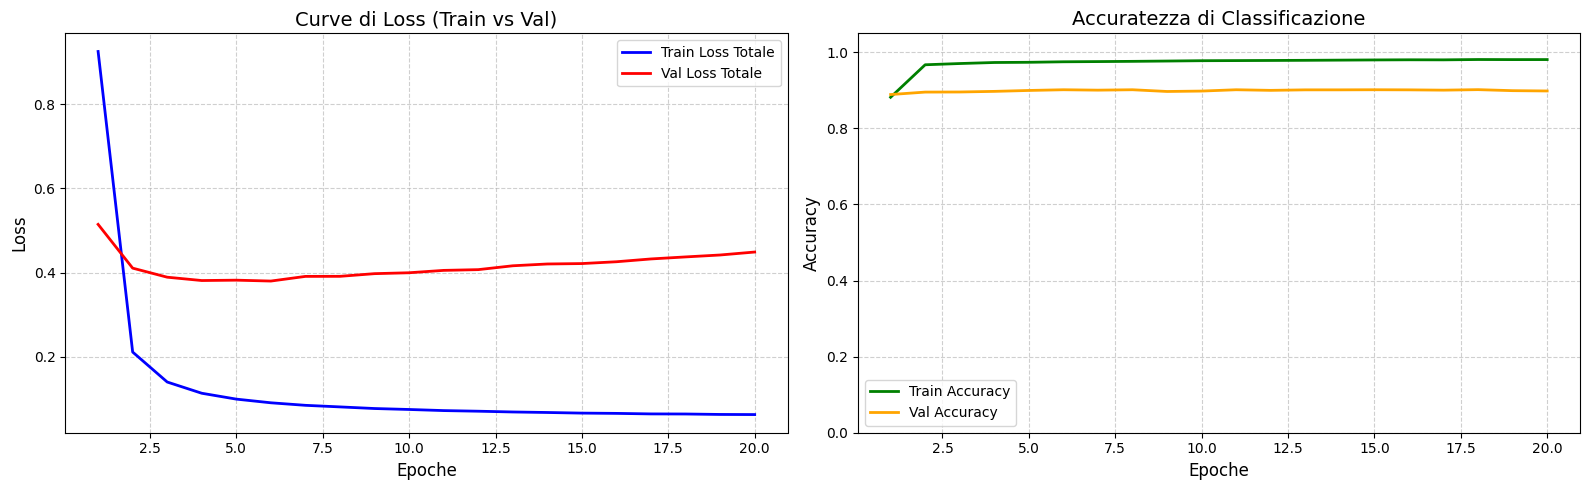

In [23]:
plot_history(cp_cls_history)

#### Test

In [24]:
cp_accuracy, cp_preds, cp_labels = test_sequential_cbm(
    cp_cls,
    cp_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.05% (6722/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       209
           1       0.84      0.95      0.89       170
           2       0.80      0.84      0.82        58
           3       0.80      0.74      0.77        38
           4       0.96      0.97      0.97       110
           5       0.93      0.93      0.93       149
           6       0.94      0.93      0.93       329
           7       0.82      0.87      0.85       207
           8       0.41      0.37      0.39        35
           9       0.79      0.84      0.82       100

   micro avg       0.86      0.90      0.88      1405
   macro avg       0.82      0.84      0.82      1405
weighted avg       0.86      0.90      0.88      1405



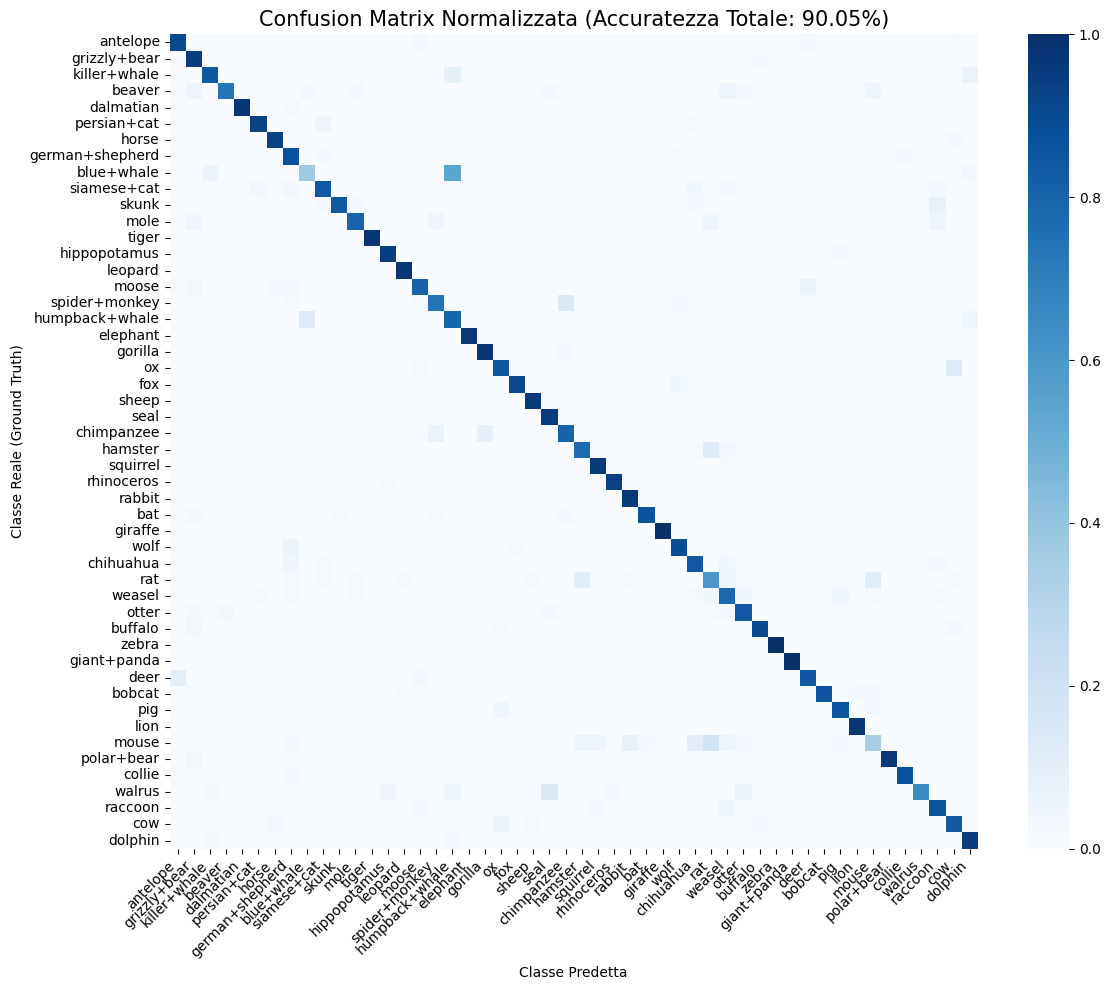


Analisi degli Errori Principali:
 - 26 volte: 'deer' è stato scambiato per 'antelope'
 - 19 volte: 'ox' è stato scambiato per 'cow'
 - 19 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 19 volte: 'hamster' è stato scambiato per 'rat'
 - 18 volte: 'humpback+whale' è stato scambiato per 'blue+whale'


In [25]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

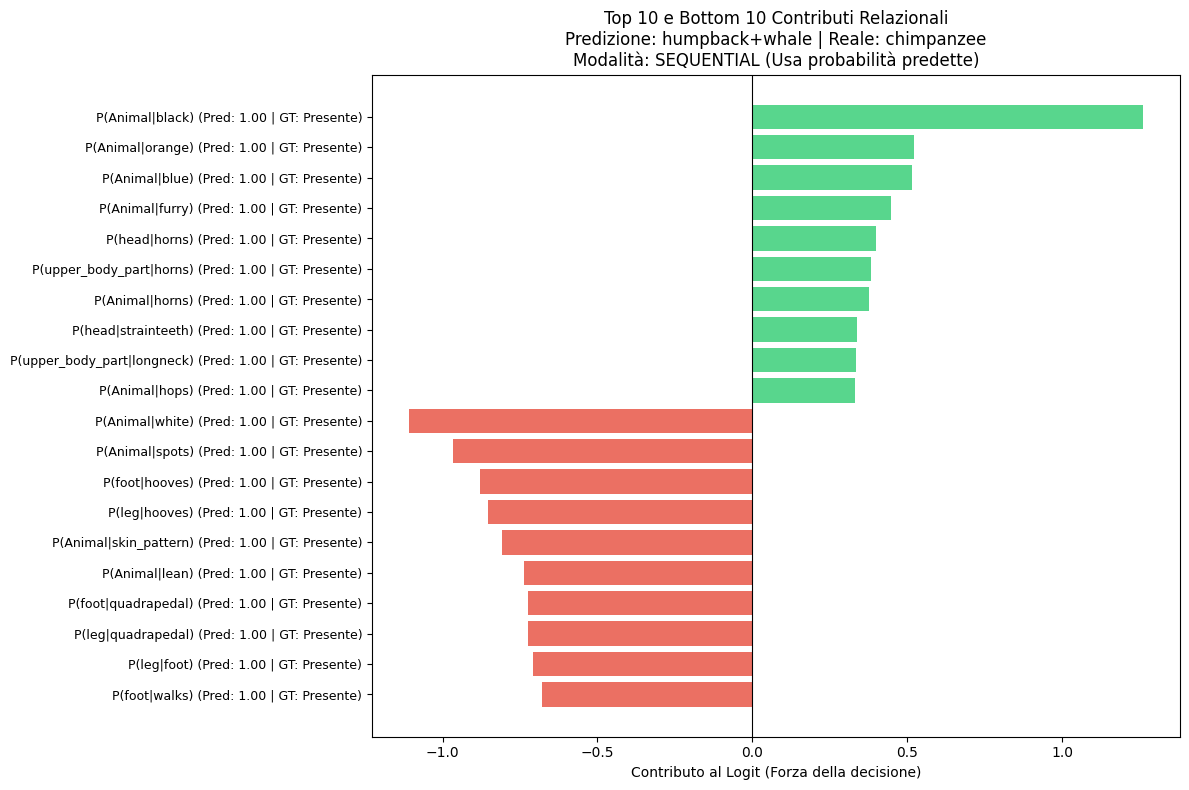

False

In [26]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=cp_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

### CBM standard

In [ ]:
info = "concepts"
c_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
c_optimizer = torch.optim.Adam(c_cls.parameters(), lr=0.001)
c_criterion = nn.CrossEntropyLoss()


c_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
c_concept_optimizer = torch.optim.Adam(c_concept_predictor.parameters(), lr=0.001)
c_concept_criterion = nn.BCEWithLogitsLoss()

c_conc_history, c_cls_history = sequential_training(
    c_cls,
    c_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    c_optimizer,  
    c_concept_optimizer,
    c_criterion,
    c_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

In [ ]:
from src.CHM.train import plot_history
plot_history(c_conc_history)

In [ ]:
plot_history(c_cls_history)

In [ ]:
c_accuracy, c_preds, c_labels = test_sequential_cbm(
    c_cls,
    c_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    c_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=c_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

### CBM ALL

#### Train

In [21]:
info = "all"
bipolar = True
a_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
a_optimizer = torch.optim.Adam(a_cls.parameters(), lr=0.001)
a_criterion = nn.CrossEntropyLoss()

a_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
a_concept_optimizer = torch.optim.Adam(a_concept_predictor.parameters(), lr=0.001)
a_concept_criterion = nn.BCEWithLogitsLoss()

a_conc_history, a_cls_history = sequential_training(
    a_cls,
    a_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    a_optimizer,  
    a_concept_optimizer,
    a_criterion,
    a_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5512 | Acc: 95.9597 || Val Loss: 2.6120 | Val Acc: 96.9740
Loss: 2.2470 | Acc: 97.4313 || Val Loss: 2.3132 | Val Acc: 97.2730
Loss: 1.9538 | Acc: 97.7360 || Val Loss: 2.1964 | Val Acc: 97.4358
Loss: 1.7835 | Acc: 97.9406 || Val Loss: 2.2205 | Val Acc: 97.4187
Loss: 1.6512 | Acc: 98.0842 || Val Loss: 2.1499 | Val Acc: 97.4830
Loss: 1.5734 | Acc: 98.1871 || Val Loss: 2.2663 | Val Acc: 97.3828
Loss: 1.4916 | Acc: 98.2749 || Val Loss: 2.1506 | Val Acc: 97.4948
Loss: 1.4324 | Acc: 98.3369 || Val Loss: 2.1901 | Val Acc: 97.5098
Loss: 1.3867 | Acc: 98.3921 || Val Loss: 2.1361 | Val Acc: 97.5291
Loss: 1.3389 | Acc: 98.4514 || Val Loss: 2.1762 | Val Acc: 97.5253
Loss: 1.2949 | Acc: 98.4940 || Val Loss: 2.2608 | Val Acc: 97.4658
Loss: 1.2654 | Acc: 98.5462 || Val Loss: 2.2185 | Val Acc: 97.5350
Loss: 1.2315 | Acc: 98.5750 || Val Loss: 2.2545 | Val Acc: 97.4701
Loss: 1.2081 | Acc: 98.6100 || Val Loss: 2.3145 | Val Ac

#### Test

In [22]:
a_accuracy, a_preds, a_labels = test_sequential_cbm(
    a_cls,
    a_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 89.86% (6708/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       209
           1       0.84      0.96      0.90       170
           2       0.78      0.86      0.82        58
           3       0.68      0.71      0.69        38
           4       0.97      0.98      0.98       110
           5       0.96      0.88      0.92       149
           6       0.92      0.95      0.93       329
           7       0.86      0.86      0.86       207
           8       0.31      0.29      0.30        35
           9       0.72      0.85      0.78       100

   micro avg       0.86      0.89      0.88      1405
   macro avg       0.80      0.82      0.81      1405
weighted avg       0.87      0.89      0.88      1405

